In [1]:
import matplotlib.pyplot as plt
import navaltoolbox as nv
from navaltoolbox.visualization import plot_vessel_3d, plot_hydrostatic_condition
from navaltoolbox.plotting import plot_criteria_result
import numpy as np

In [2]:
# Water density
rho = 1025.0

# Vessel
hull = nv.Hull("trawler.stl")
hull.scale(0.001)  # Mesh file was created in mm
vessel = nv.Vessel(hull)

# Parameters (these parameters are not necessarily equal to the ones calculated by navaltoolbox)
breadth = 5.0
depth = 2.15
draft = 1.7
ap = 0.0  # This can be changed to the rudder axis position
fp = 16.42  # Intersection of the bow with the waterline
lbp = fp - ap  # For now, Length Between Perpendiculars = Waterline Length
mp = ap + 0.5*lbp  # Midship perpendicular

# submerged_volume = 72.575719  # Computed with FreeCAD
displacement = 74407  # Computed with navaltoolbox.

# Silhouette
silhouette = nv.Silhouette("windage.csv")
vessel.add_silhouette(silhouette)

emerged_area = silhouette.get_area()
emerged_centroid = silhouette.get_centroid()
submerged_centroid = [8.72, 0.95]  # Computed with FreeCAD

print(f"Windage area: {emerged_area:.2f}m²")  # FreeCAD: 69.14 m²
print(f"Windage centroid: x = {emerged_centroid[0]:.2f}m, y = {emerged_centroid[1]:.2f}m")  # FreeCAD: 8.82m, 3.93m

Windage area: 69.14m²
Windage centroid: x = 8.82m, y = 3.93m


In [3]:
# Gross Tonnage
Vs = 85.030199  # Volume of superstructure (computed with FreeCAD)
Vh = 103.875365  # Volume of hull below main deck (computed with FreeCAD)
Vt = Vs + Vh  # Volume of enclosed spaces

# Only the volume below the main deck is used to compute the gross tonnage.
V = Vh
K1 = 0.2 + 0.02 * np.log10(V)
GT = K1 * V

print(f"Gross Tonnage: {GT:.0f}")

Gross Tonnage: 25


In [4]:
# Estimation of weight parameters.
# The parameter α, β and γ define the loading condition.
# The following values determine the condition of full load departure.
alpha = 1.0
beta = 1.0
gamma = 0.0

# Weight
W0 = 2.434*GT
W1 = 0.355*GT
W2 = 0.209*GT
W3 = 0.024*GT
W4 = 0.167*GT
W5 = 1.320*GT

W = W0 + alpha*(W1 + W2 + W3) + beta*W4 + gamma*W5

# LCG
LCG0 =  0.160*GT + 3.556
LCG1 =  0.168*GT + 2.421
LCG2 = -0.223*GT - 4.221 + mp
LCG3 = -0.258*GT - 3.522 + mp
LCG4 =  0.420*GT + 4.427
LCG5 =  0.272*GT + 6.549

LCG = (W0*LCG0 + alpha*(W1*LCG1 + W2*LCG2 + W3*LCG3) + beta*W4*LCG4 + gamma*W5*LCG5) / W

# KG
KG0 = 0.029*GT + 0.840
KG1 = 0.030*GT + 0.384
KG2 = 0.027*GT + 1.273
KG3 = 0.055*GT + 1.378
KG4 = 0.004*GT + 1.082
KG5 = 0.029*GT + 0.269

KG = (W0*KG0 + alpha*(W1*KG1 + W2*KG2 + W3*KG3) + beta*W4*KG4 + gamma*W5*KG5) / W

print(f"Estimated displacement: {W:.1f}t")
print(f"Estimated LCG: {LCG:.3f}m")
print(f"Estimated KG: {KG:.3f}m")

Estimated displacement: 79.6t
Estimated LCG: 7.163m
Estimated KG: 1.530m


In [5]:
# Position of the center of gravity. lcg = LCB, and the vcg was estimated previously.
lcg, tcg, vcg = 7.94, 0.0, KG
cg = (lcg, tcg, vcg)

In [6]:
# Downflooding Openings
p1 = ( 9.060,  1.122, 2.655)
p2 = (10.450, -0.090, 2.655)
p3 = (11.587, -0.020, 2.655)
p4 = ( 9.631,  0.090, 4.610)
p5 = (12.420,  1.284, 4.610)

otype = nv.OpeningType.door()

door1 = nv.DownfloodingOpening.from_point("Door 1", p1, opening_type=otype)
door2 = nv.DownfloodingOpening.from_point("Door 2", p2, opening_type=otype)
door3 = nv.DownfloodingOpening.from_point("Door 3", p3, opening_type=otype)
door4 = nv.DownfloodingOpening.from_point("Door 4", p4, opening_type=otype)
door5 = nv.DownfloodingOpening.from_point("Door 5", p5, opening_type=otype)

vessel.add_opening(door1)
vessel.add_opening(door2)
vessel.add_opening(door3)
vessel.add_opening(door4)
vessel.add_opening(door5)

Door 1 is submerged = False
Door 2 is submerged = False
Door 3 is submerged = False
Door 4 is submerged = False
Door 5 is submerged = False


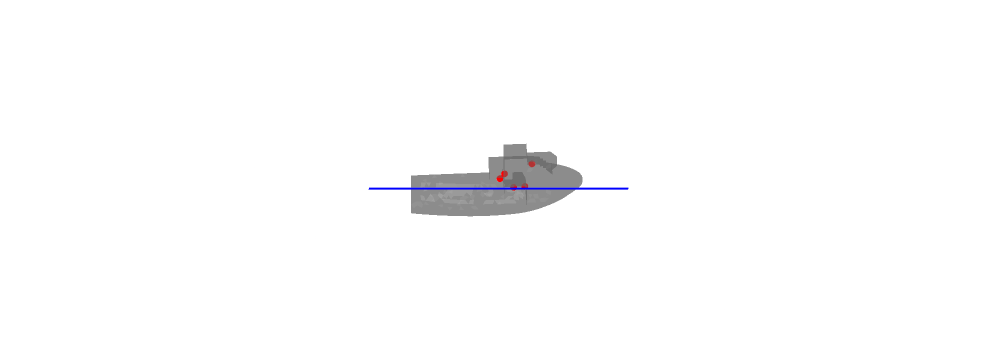

In [7]:
# After some tests, it was noted that the is_submerged attribute of the DownfloodingOpening object
# does not always return the correct value. The hydrostatic condition is plotted to double check it.

hydro_calc = nv.HydrostaticsCalculator(vessel, water_density=rho)

state = hydro_calc.from_displacement(displacement, cog=cg, heel=50)

print("Door 1 is submerged =", door1.is_submerged(state.heel, state.trim, (0, 0, 0), state.draft))
print("Door 2 is submerged =", door2.is_submerged(state.heel, state.trim, (0, 0, 0), state.draft))
print("Door 3 is submerged =", door3.is_submerged(state.heel, state.trim, (0, 0, 0), state.draft))
print("Door 4 is submerged =", door4.is_submerged(state.heel, state.trim, (0, 0, 0), state.draft))
print("Door 5 is submerged =", door5.is_submerged(state.heel, state.trim, (0, 0, 0), state.draft))

fig = plot_hydrostatic_condition(
    vessel,
    draft=state.draft,
    trim=state.trim,
    heel=state.heel,
    title=None,
    show_silhouettes=False,
    enable_opacity_slider=False,
    show_axes=False
)

# Remove the perpendiculars from the plot
fig.data = tuple(
    trace for trace in fig.data 
    if trace['name'] != 'Perpendiculars'
)

# Hide the menu buttons and legend, zero the margin and adjust the camera angle to the bow.
fig.update_layout(
    updatemenus=[dict(visible=False)],
    showlegend=False,
    margin=dict(l=0, r=0, t=0, b=0),
    scene=dict(
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=1, y=0, z=0),
            up=dict(x=0, y=0, z=1),
        ),
    ),
)

fig.write_image("hydro_cond_heel_50deg_bow.png", width=800, height=500, scale=3)

# Adjust the camera angle to the starboard.
fig.update_layout(
    scene=dict(
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0, y=-1, z=0),
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
        ),
    ),
)

fig.write_image("hydro_cond_heel_50deg_starboard.png", width=800, height=500, scale=3)

fig.show()

In [8]:
# Stability Calculator
stab_calc = nv.StabilityCalculator(vessel, water_density=rho)

heels = np.linspace(-180, 180, 501)

result = stab_calc.complete_stability(displacement_mass=displacement, cog=cg, heels=heels)

Hydrostatics
Cb: 0.55
Draft: 1.70m
Lwl: 16.42m
Aw: 68.65m²
LCF: 7.38m
KB: 1.09m
GMT: 1.14m

GZ Curve


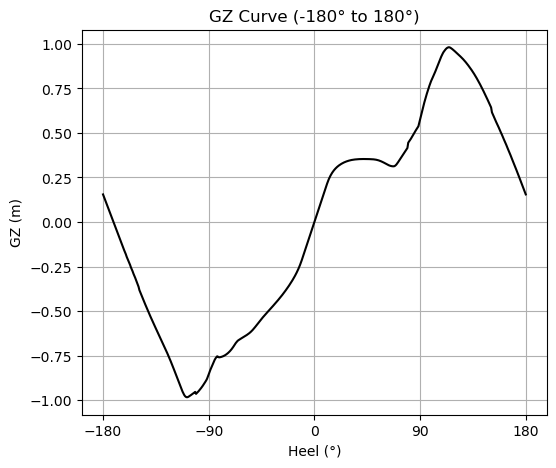

In [9]:
print("Hydrostatics")
print("============")
print(f"Cb: {result.hydrostatics.cb:.2f}")
print(f"Draft: {result.hydrostatics.draft:.2f}m")
print(f"Lwl: {result.hydrostatics.lwl:.2f}m")
print(f"Aw: {result.hydrostatics.waterplane_area:.2f}m²")
print(f"LCF: {result.hydrostatics.lcf:.2f}m")
print(f"KB: {result.hydrostatics.cob[2]:.2f}m")
print(f"GMT: {result.hydrostatics.gmt:.2f}m")

print("\nGZ Curve")
print("========")
gz = result.gz_curve

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title("GZ Curve (-180° to 180°)")
ax.set_xlabel("Heel (°)")
ax.set_ylabel("GZ (m)")
ax.set_xticks([-180, -90, 0, 90, 180])
ax.grid()

ax.plot(gz.heels(), gz.values(), 'k')

fig.savefig("gz_curve.svg", bbox_inches="tight")

plt.show()

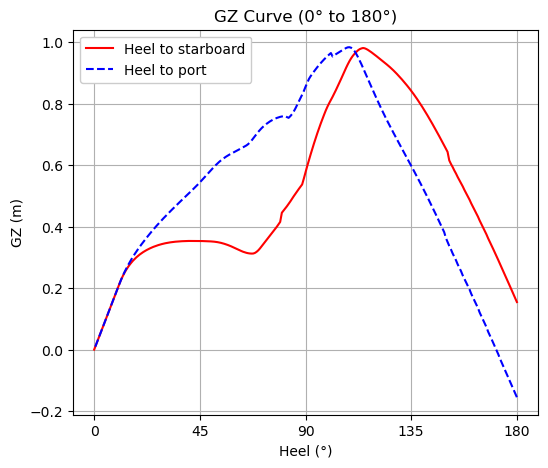

In [10]:
gz_heels = np.array(gz.heels())
gz_values = np.array(gz.values())

stb_mask = gz_heels >= 0
prt_mask = gz_heels <= 0

gz_heels_stb = gz_heels[stb_mask]
gz_heels_prt = -gz_heels[prt_mask]

gz_values_stb = gz_values[stb_mask]
gz_values_prt = -gz_values[prt_mask]

fig, ax = plt.subplots(figsize=(6,5))

ax.set_title("GZ Curve (0° to 180°)")
ax.set_xlabel("Heel (°)")
ax.set_ylabel("GZ (m)")
ax.set_xticks([0, 45, 90, 135, 180])
ax.grid()

ax.plot(gz_heels_stb, gz_values_stb, 'r-', label="Heel to starboard")
ax.plot(gz_heels_prt, gz_values_prt, 'b--', label="Heel to port")

ax.legend(framealpha=1)

fig.savefig("gz_curve_prt_stb.svg", bbox_inches="tight")

plt.show()

2.2.1 Area 0-30    = 0.122 m⋅rad (reference value = 0.055 m⋅rad) → PASS
2.2.1 Area 0-40    = 0.183 m⋅rad (reference value = 0.090 m⋅rad) → PASS
2.2.1 Area 30-40   = 0.061 m⋅rad (reference value = 0.030 m⋅rad) → PASS
2.2.2 Min GZ Value = 0.346 m     (reference value = 0.200 m)     → PASS
2.2.3 Max GZ Angle = 40.854 °    (reference value = 25.000 °)    → PASS
2.2.4 GM0          = 1.136 m     (reference value = 0.150 m)     → PASS
2.3.1 Equilibrium  = 7.172 °     (reference value = 16.000 °)    → PASS
2.3.1 Weather      = 0.079 m⋅rad (reference value = 0.119 m⋅rad) → FAIL


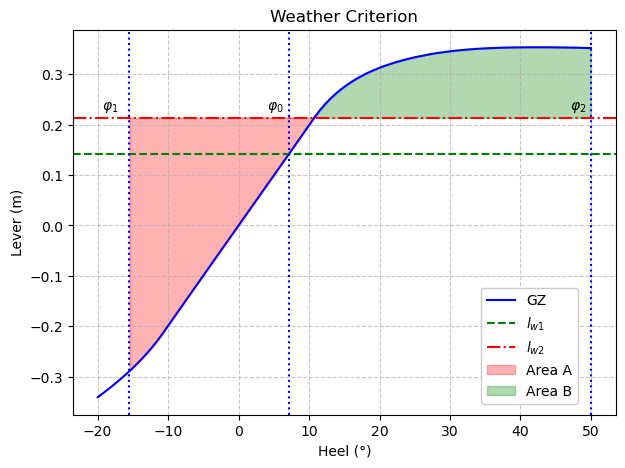

In [11]:
# Check the results against the International Code on Intact Stability (2008).
heels = np.linspace(-20.0, 50.0, 200)

result = stab_calc.complete_stability(displacement_mass=displacement, cog=cg, heels=heels)

ctx = nv.CriteriaContext.from_result(result, "Trawler", "Design")

# NavalToolbox computes the wind lever arm incorrectly:
#     let wind_lever_arm = emerged_centroid[1] - waterline_z;
# Instead of waterline_z, it was supposed to be half the draft or the centroid of the submerged area.
# This is fixed by providing a parameter to the script.
wind_lever_arm = emerged_centroid[1] - submerged_centroid[1]
lw1 = 504 * emerged_area * wind_lever_arm / (9.81 * displacement)
ctx.set_param('lw1', lw1)

# The original script uses the waterline breadth, while it should be the moulded breadth.
# The parameter below fixes this.
ctx.set_param('breadth', breadth)

engine = nv.ScriptEngine()
criteria = engine.run_script_file("is_code_2008.rhai", ctx)

for c in criteria.criteria:
    caval = f'{c.actual_value:.3f}' + ' ' +  c.unit
    crval = f'{c.required_value:.3f}' + ' ' +  c.unit + ')'
    print(f"{c.name:<18} = {caval:<11} (reference value = {crval:<12} → {c.status}")

fig = nv.plotting.plot_criteria_result(criteria, show=False)[0]

fig.set_size_inches(7, 5)
ax = fig.axes[0]

lines = ax.get_lines()
lines[2].set_linestyle("dashdot")

lines[1].set_label(r"$l_{w1}$")
lines[2].set_label(r"$l_{w2}$")

ax.text(4.1, 0.23, r"$\varphi_0$")
ax.text(-19.4, 0.23, r"$\varphi_1$")
ax.text(47, 0.23, r"$\varphi_2$")

ax.legend(loc='lower left', bbox_to_anchor=(0.74, 0.01), framealpha=1)

fig.savefig('weather_criterion.svg', bbox_inches='tight')